### Purpose of this notebook
# Explore a high level overview of DCE crush spread relationships
* Thesis:
* Is the relationship cointegrated?
* Do the coefficients match in sign and weight as the underlying extraction economics?
* What is the half life frequency when the spread dislocates?



In [1]:
import sys
from pathlib import Path
from unittest import result

from matplotlib import pyplot as plt

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import akshare as ak
import seaborn as sns

from theme import set_theme
palette = sns.color_palette()

from src.research.asia_ingest import (
    soy_complex_symbols,
    OHLCV_FIELDS,
    fetch_sina_ohlcv,
    to_ohlcv_panel,
)

set_theme()

{'rc_params': {'figure.facecolor': '#282c34',
  'axes.facecolor': '#282c34',
  'savefig.facecolor': '#282c34',
  'axes.edgecolor': '#3e4451',
  'axes.labelcolor': '#abb2bf',
  'text.color': '#abb2bf',
  'xtick.color': '#abb2bf',
  'ytick.color': '#abb2bf',
  'axes.grid': True,
  'grid.color': '#3e4451',
  'grid.linewidth': 0.6,
  'grid.linestyle': '-',
  'font.size': 9},
 'palette': ['#61afef', '#98c379', '#e5c07b', '#d19a66', '#c678dd', '#e06c75']}

In [4]:
# Soy Complex symbols to pull
soy_complex_symbols = {
    "A0": "bean1",
    "B0": "bean2",
    "M0": "meal",
    "Y0": "oil"
}

long_sb = fetch_sina_ohlcv(soy_complex_symbols)
df = to_ohlcv_panel(long_sb)

# modify multi level index structure into xs per contract
df_flat = df.xs("close", level="field", axis=1)
df_flat

name,bean1,bean2,meal,oil
date,,,,
2005-01-04,2868.0,NaN,2150.0,NaN
2005-01-05,2885.0,NaN,2154.0,NaN
2005-01-06,2889.0,NaN,2167.0,NaN
2005-01-07,2893.0,NaN,2182.0,NaN
2005-01-10,2885.0,NaN,2177.0,NaN
...,...,...,...,...
2026-09-02,4972.0,4122.0,3361.0,9113.0
2026-09-03,4978.0,4137.0,3382.0,9123.0
2026-09-04,5003.0,4198.0,3423.0,9165.0


In [5]:
# additional index manipulation
idx = pd.IndexSlice
sub = df.loc[:, idx[:, ["close", "volume"]]]
flat = sub.copy()
flat.columns = [f"{name}_{field}" for name, field in flat.columns]
ts = flat.dropna()
ts.tail()

# Save df to parquet
ts.to_parquet(PROJECT_ROOT/"data"/"raw"/"soy_complex_flat.parquet")

In [6]:
# Import timeseries
df = pd.read_parquet(PROJECT_ROOT/"data"/"raw"/"soy_complex_flat.parquet")
df.tail()

,bean1_close,bean1_volume,bean2_close,bean2_volume,meal_close,meal_volume,oil_close,oil_volume
date,,,,,,,,
2026-09-02,4972.0,384026.0,4122.0,290857.0,3361.0,1742143.0,9113.0,596652.0
2026-09-03,4978.0,249017.0,4137.0,336724.0,3382.0,1921252.0,9123.0,595560.0
2026-09-04,5003.0,216735.0,4198.0,268869.0,3423.0,1781974.0,9165.0,420097.0
2026-09-07,5021.0,234073.0,4172.0,221061.0,3408.0,1415266.0,9172.0,385896.0
2026-09-08,5146.0,437317.0,4166.0,263052.0,3415.0,1451945.0,9189.0,465004.0


In [7]:
# add a log return column for every *_close column

def build_log_returns(df: pd.DataFrame, cols: str) -> pd.DataFrame:
    """ Takes in dataframe with argument for which column to log """
    cols = [c for c in df.columns if c.endswith(cols)]
    for col in cols:
        new_col = f"{col}_log_return"
        df[new_col] = np.log(df[col] / df[col].shift(1))
    return df

df = build_log_returns(df, "_close")
df.tail()

,bean1_close,bean1_volume,bean2_close,bean2_volume,meal_close,meal_volume,oil_close,oil_volume,bean1_close_log_return,bean2_close_log_return,meal_close_log_return,oil_close_log_return
date,,,,,,,,,,,,
2026-09-02,4972.0,384026.0,4122.0,290857.0,3361.0,1742143.0,9113.0,596652.0,-0.002411,-0.004840,-0.004749,0.001647
2026-09-03,4978.0,249017.0,4137.0,336724.0,3382.0,1921252.0,9123.0,595560.0,0.001206,0.003632,0.006229,0.001097
2026-09-04,5003.0,216735.0,4198.0,268869.0,3423.0,1781974.0,9165.0,420097.0,0.005010,0.014637,0.012050,0.004593
2026-09-07,5021.0,234073.0,4172.0,221061.0,3408.0,1415266.0,9172.0,385896.0,0.003591,-0.006213,-0.004392,0.000763
2026-09-08,5146.0,437317.0,4166.0,263052.0,3415.0,1451945.0,9189.0,465004.0,0.024591,-0.001439,0.002052,0.001852


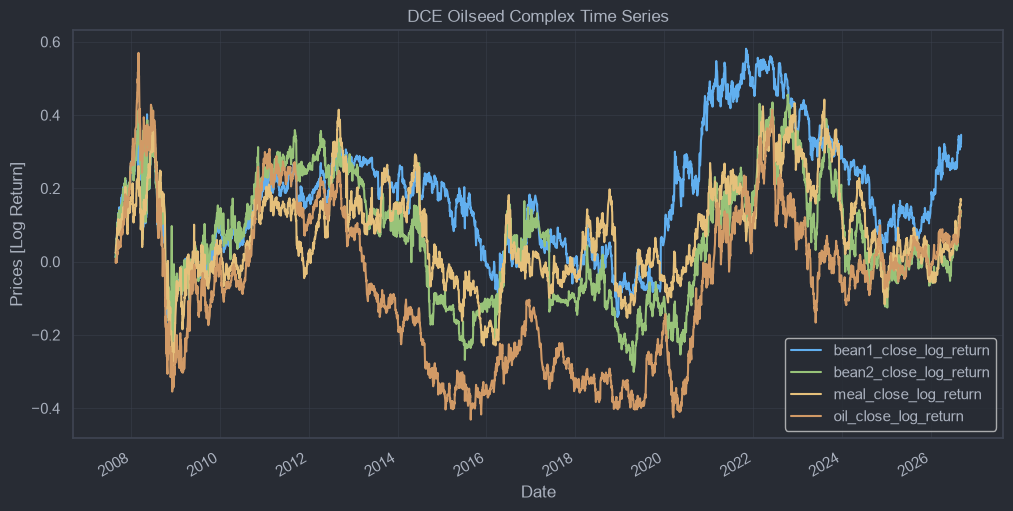

In [8]:
# Isolate log return columns
log_cols = [c for c in df.columns if c.endswith("_log_return")]

# Plot series
fig, ax1 = plt.subplots(figsize=(12, 6))
df[log_cols].cumsum().plot(ax=ax1)
ax1.set(
    xlabel="Date",
    ylabel="Prices [Log Return]",
    title="DCE Oilseed Complex Time Series"
)
plt.show()

In [9]:
# Confirm stationarity of series using AdFuller Test
log_df = df[log_cols].dropna()

result =  adfuller(log_df["bean2_close_log_return"], result_object=True)
print(result)
print(f"p_value: {result.pvalue}")

ADFullerResult
ADF Statistic: -14.78302
P-value: 0.00000
Used Lag: 20
Nobs: 4455
Critical Values: {'1%': np.float64(-3.431818703008641), '5%': np.float64(-2.862188990440011), '10%': np.float64(-2.567115461397867)}

p_value: 2.2303373055662943e-27


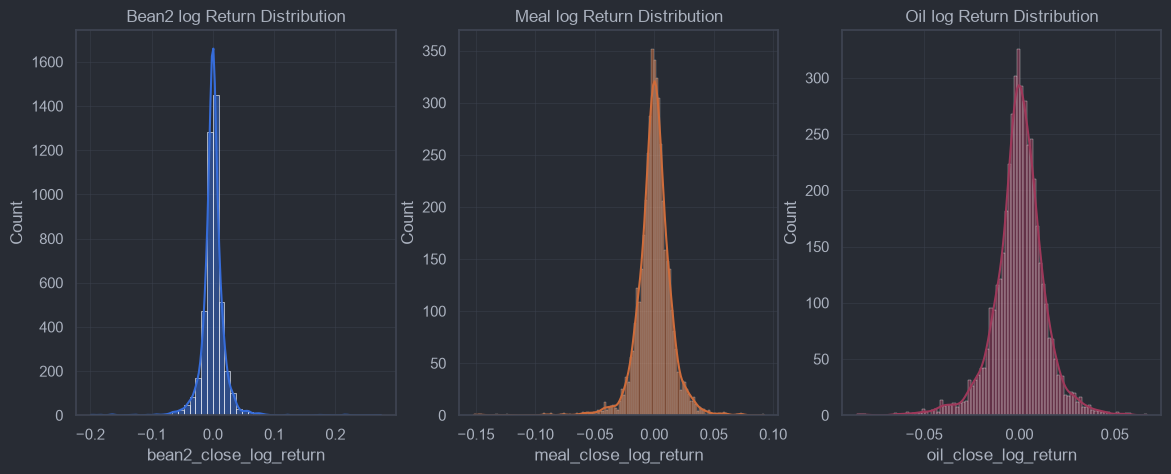

Skew Data:

bean1_close_log_return is right skewed
bean2_close_log_return is right skewed
meal_close_log_return is left skewed
oil_close_log_return is left skewed

bean1_close_log_return    0.426618
bean2_close_log_return    0.418702
meal_close_log_return    -1.163363
oil_close_log_return     -0.453823
dtype: float64


In [13]:
fig, axs= plt.subplots(1,3, figsize=(14, 5))
sns.histplot(df["bean2_close_log_return"], bins=50, alpha=0.5, color=palette[0], kde=True, ax=axs[0])
sns.histplot(df["meal_close_log_return"], alpha=0.5, color=palette[1], kde=True, ax=axs[1])
sns.histplot(df["oil_close_log_return"], alpha=0.5, color=palette[2], kde=True, ax=axs[2])
axs[0].set_title("Bean2 log Return Distribution")
axs[1].set_title("Meal log Return Distribution")
axs[2].set_title("Oil log Return Distribution")
plt.show()

# Are the series skewed to the left or right distribution
print("Skew Data:")
print()
for col in log_cols:
    if df[col].skew() > 0:
        print(f"{col} is right skewed")
    else:
        print(f"{col} is left skewed")

print()
print(df[log_cols].skew())



<Axes: >

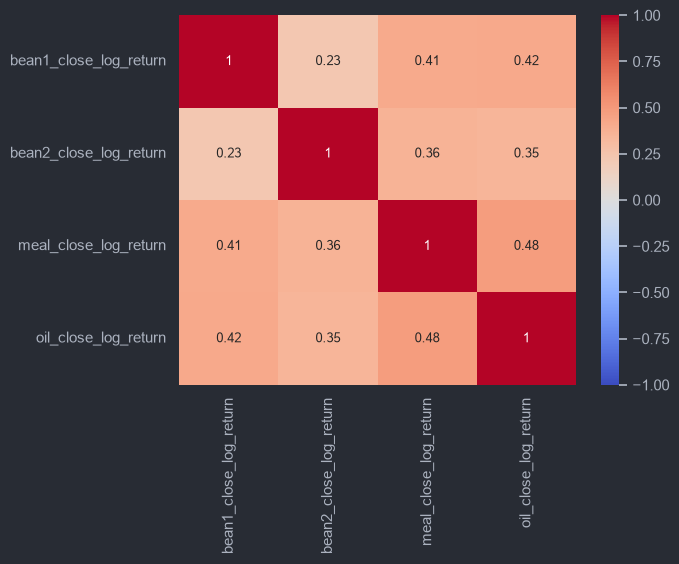

In [9]:
fig, ax = plt.subplots()
correlation = df[log_cols].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
